# Individual Study Project: Analysis of High-Redshift Galaxies with NIRSpec

This notebook contains a spectral fitting tool developed during an research stay at the Niels Bohr Institute (University of Copenhagen).

The data were obtained from the DJA (DAWN JWST Archive) database and consist of NIRSpec spectra of galaxies in the redshift range \(5 < z < 7\). The sample was selected to include sources with prominent emission lines and a well-defined Ly$\alpha$ region. For this redshift interval, the Ly$\alpha$ line (\(\lambda_{\rm rest}=1215.67\) Å) is observed approximately between 729.4 and 972.5 nm.

### Workflow
**Part 1:** Data loading, preprocessing, and continuum fitting using an eighth-degree polynomial.

**Part 2:** Fitting of prominent emission lines in the continuum-normalized spectra using `scipy.optimize.curve_fit`.

**Part 3:** Modeling of the Ly$\alpha$ region with Voigt profiles following the analytic approximation presented in *"Voigt Profile Fitting to Quasar Absorption Lines: An Analytic Approximation to the Voigt-Hjerting Function"* by Tepper-García (2006), allowing constraints on the neutral hydrogen column density.

In [2]:
#Import libraries 
import numpy as np
from astropy.utils.data import download_file
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.table import Table
import os
from astropy.visualization import quantity_support
from specutils import Spectrum1D
from astropy import units as u
quantity_support() 
import warnings
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from scipy.ndimage import gaussian_filter1d
from scipy.signal import fftconvolve
import astropy.constants as const
from astropy.constants import c
from PIL import Image
from IPython.display import display

The data was obtain in the next webpage:
https://s3.amazonaws.com/msaexp-nirspec/extractions/nirspec_graded.html?&z_min=5&z_max=7&sn50_min=3
Note: We did not automatize the process because spectra needs to be selected by eye. 
In the webpage you can select spectra with the selected parameters needed for you study, in this case 5<z<7. This is because we want to study the Lyman $\alpha$ region.

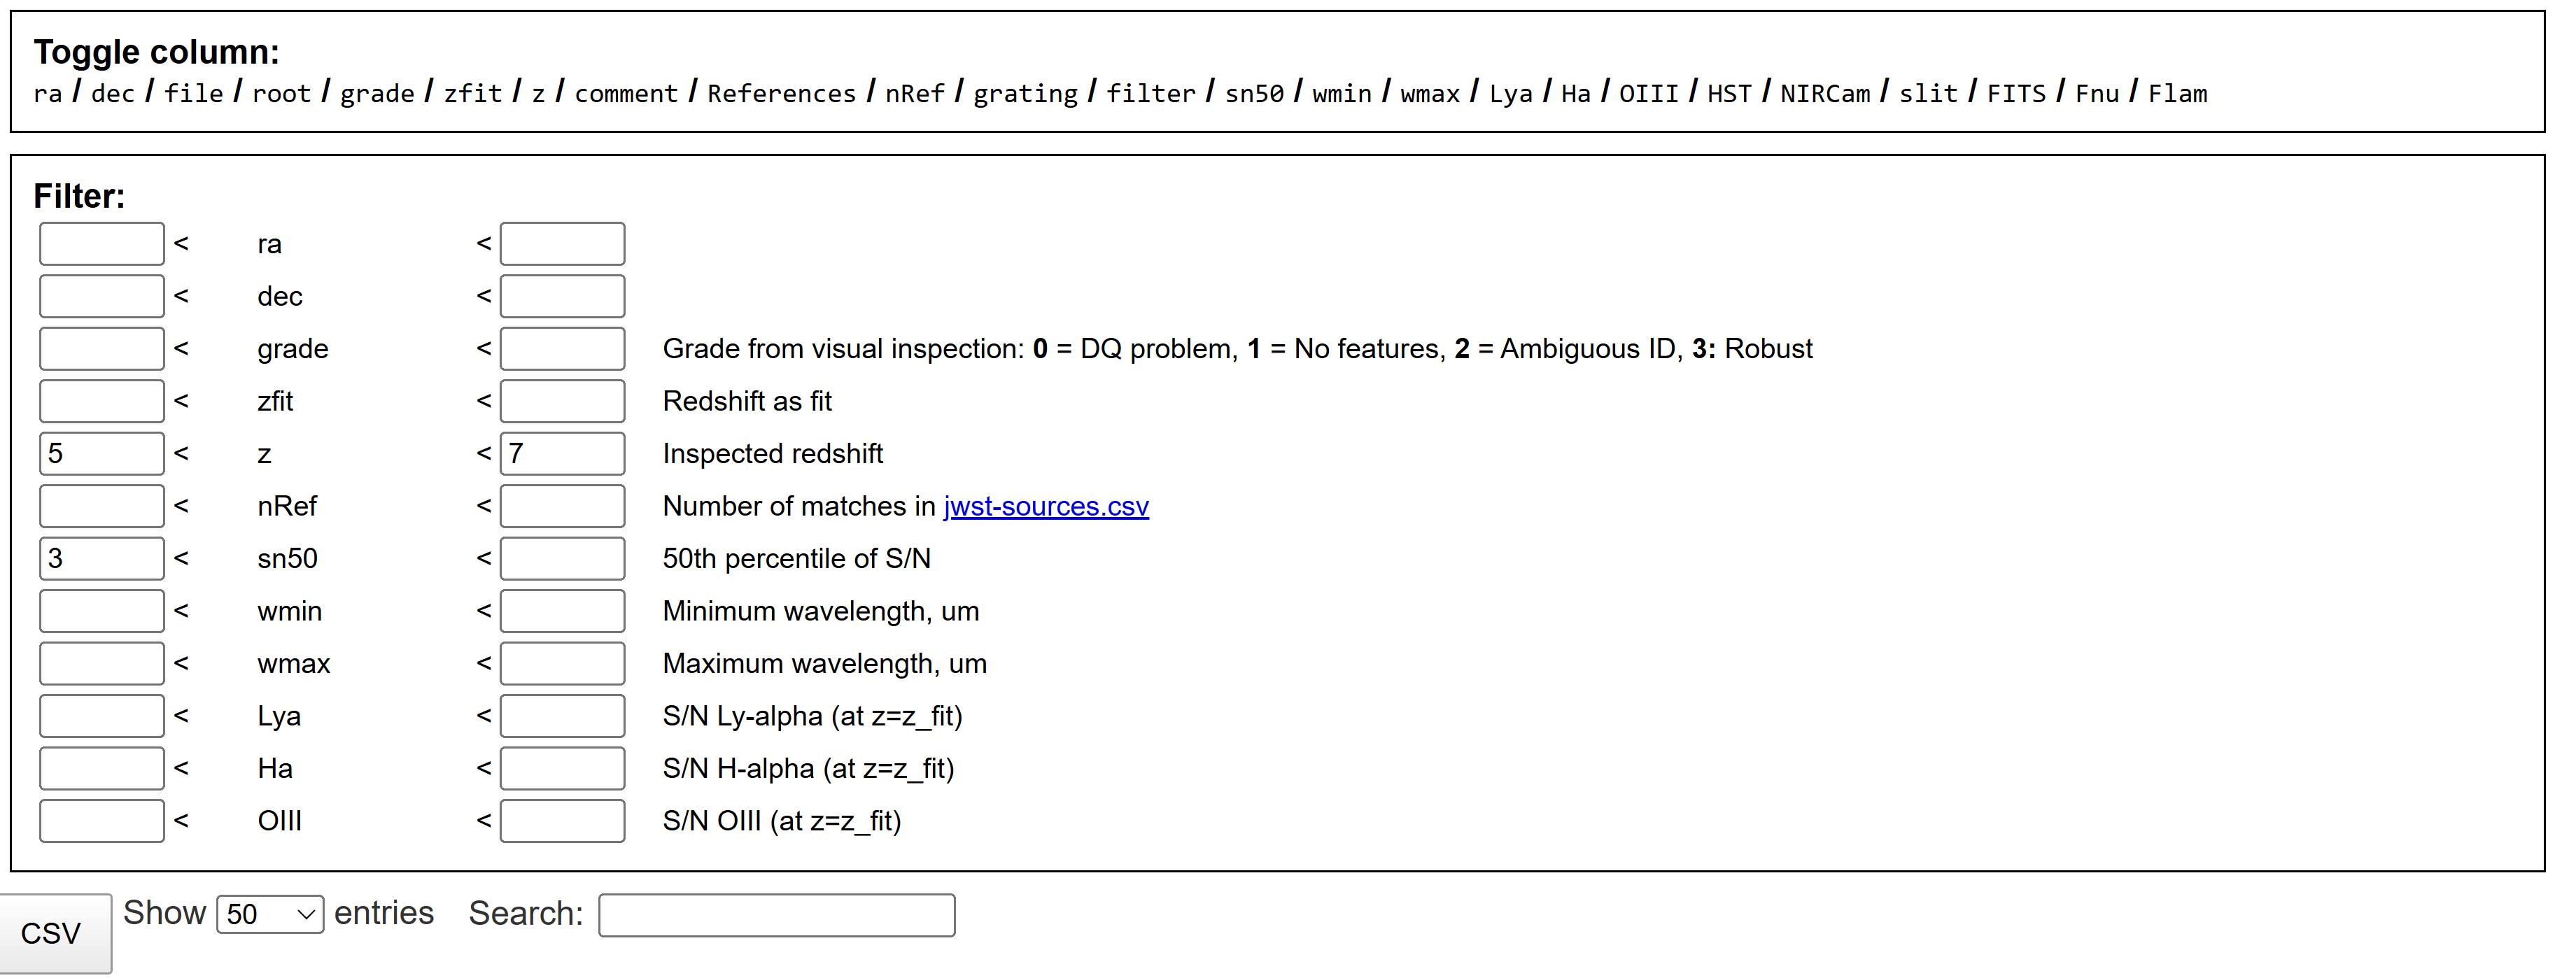

In [4]:
img = Image.open("DJA1.png")
display(img)

This is how the webpage looks you can adjust the redshift o S/N depeding of your study. 

One of the selected galaxy files was the next one: "ceers-ddt-v1_prism-clear_2750_663". We open and check the data format and the spectra.

In [7]:
# Here we read in a FITS table
filename = 'ceers-ddt-v1_prism-clear_2750_663.spec.fits' 
hdu_list = fits.open(filename, memmap=True)
evt_data = Table(hdu_list[1].data)
#Show first 10 rows
evt_data[1:10]

wave,flux,err
float64,float64,float64
0.5836851085753291,0.0,0.0
0.5874378771811705,0.0,0.0
0.591260215571612,0.0,0.0
0.5951542612478814,0.0,0.0
0.5991219350103587,0.0,0.0
0.6031652486825945,0.012837036432488211,0.012908552853888523
0.6072866429848921,-0.0021349992399149072,0.005202682550824569
0.6114883288153422,0.004396027933659225,0.005734357048472488
0.6157725852112719,-0.005402396125514243,0.005811961805637592


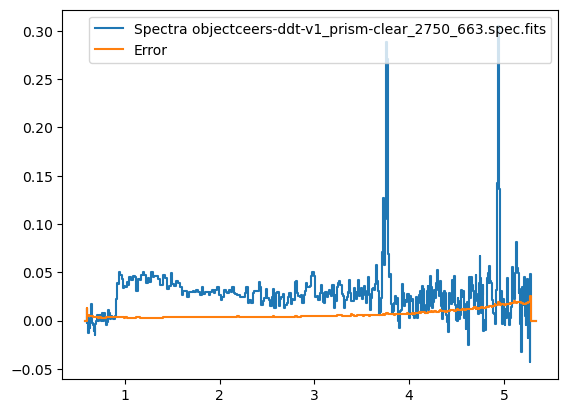

In [8]:
#Plot data and error
plt.step(evt_data['wave'],evt_data['flux'],label='Spectra object'+filename)
plt.step(evt_data['wave'],evt_data['err'],label='Error')
plt.legend()

## First part: Transformation and normalization of data

## Transformation $F_{\nu}$ to $F_{\lambda}$

Since data in our notebook is flux in frequency units we need to convert to flux in wavelength.  

This is done using a simple formula:


$f_{\lambda}=\frac{f_{\nu} ~c}{\lambda^2}$

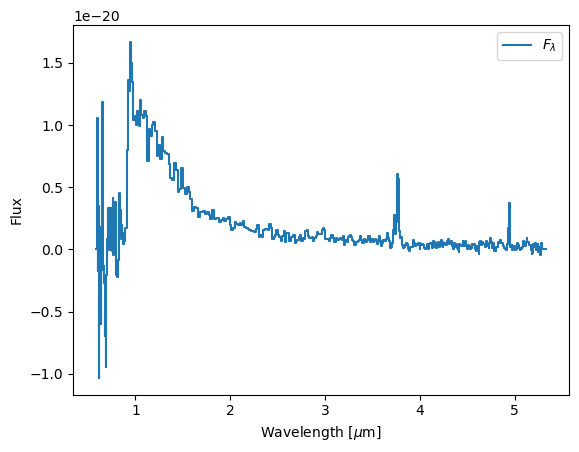

In [12]:
#Rename data
flux=evt_data["flux"]
wave=evt_data["wave"]
#Redshift and the speed of light
zobj2=6.5357 #Reported redshift
#For the speed of ligh c.cgs.value gives us approximatly c= 2.99792e10

#Here we change the frequency to wavelegth (lambda)
#This include a factor 1e-29 when we change from Jansky
flux1=(flux*c.cgs.value*(1e-29))/(wave)**2
errors=(evt_data["err"]*c.cgs.value*(1e-29))/(wave)**2 
plt.step(wave,flux1,label='$F_{\lambda}$')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux')
plt.legend()

### Fit of continuum and normalization

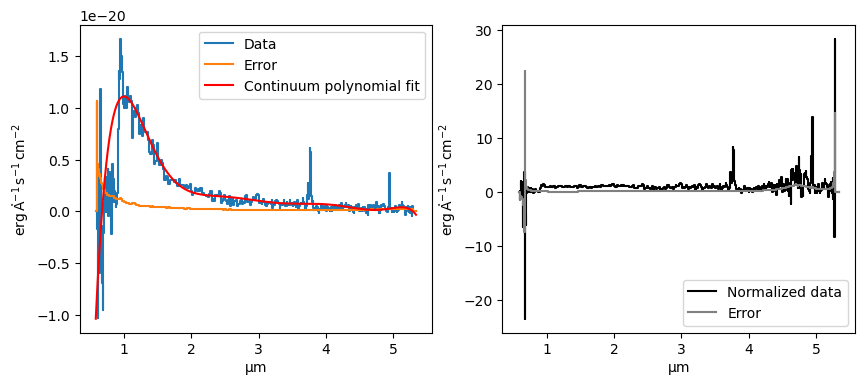

In [14]:
#Fit of continuum

#Change data to spectrum and assign units
spec = Spectrum1D(flux=flux1* u.Unit('erg cm-2 s-1 AA-1'), spectral_axis=wave* u.um  ) 
spec2 = Spectrum1D(flux=errors* u.Unit('erg cm-2 s-1 AA-1'), spectral_axis=wave* u.um  ) 

#Here we make a tailored mask to fit the regions of the continuum
nt=np.where((0.9<wave) & (wave<2.7)|(2.9<wave) & (wave<3.1)|(3.3<wave) & (wave<3.5)|(3.75<wave) & (wave<4.8)
|(5<wave) & (wave<6))
#Select a polynomial degree 8 to fit the data
c1 = np.polyfit(wave[nt],flux1[nt], 8)
facF = np.poly1d(c1)(wave)

#Normalize spectrum with continuum
cont_norm_spec = spec / facF
cont_norm_spec_error = spec2 / facF
errorn=spec2/facF    
shift=200#310
wavef=(cont_norm_spec.spectral_axis.to_value()*1e4)+shift


#Lines to check continuum fit
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].step(cont_norm_spec.spectral_axis,spec.flux,label='Data')
ax[0].step(cont_norm_spec.spectral_axis,spec2.flux,label='Error')
ax[0].plot(cont_norm_spec.spectral_axis,facF,color='red',label='Continuum polynomial fit')
ax[0].legend()


ax[1].step(cont_norm_spec.spectral_axis,cont_norm_spec.flux,label='Normalized data',color='Black')
ax[1].step(cont_norm_spec_error.spectral_axis,cont_norm_spec_error.flux,label='Error',color='Grey')
ax[1].legend()

## Second part: Emission line fitting 

In this section we define a Gaussian function gauss to fit the emission lines. Then the calculation of integrated flux, luminosity and SFR for H$\alpha$ emission line.

In [17]:
# Gauss function to fit emission lines
def gauss(x, a, x0, sigma, b,c):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))+(b*x+c)

# Rename data
x = wave
y = flux1


# Restrictions/ this changes for each spectra
x_restricted1 = x[(x >= 2.5) & (x <= 2.9)]
y_restricted1 = y[(x >= 2.5) & (x <= 2.9)]

x_restricted2 = x[(x >= 3.75) & (x <= 4.9)]
y_restricted2 = y[(x >= 3.75) & (x <= 4.9)]

x_restricted = x[(x >= 4.2) & (x <= 5.1)]
y_restricted = y[(x >= 4.2) & (x <= 5.1)]

x_restricted3 = x[(x >= 3.3) & (x <= 5.5)]
y_restricted3 = y[(x >= 3.3) & (x <= 5.5)]

# Gaussian fit with initial guess
#Initial conditions for the fit
if_alpha=3.49e-21 #This parameter allows to tied Halpha and Hbeta, since the kinematic components are. 
#That later in the fit Hbeta was divided by the number 2.86. This number is a theoretical number that relates both emission lines.
if_OII=3e-21
if_OIII=4e-21
iw_alpha=0.01
b = -0.1e-22
c = 1e-21    

#Using curve fit to fit a Gaussian in each line/curve_fit(function,filtered_spectra,initial_parameters)
popt, pcov = curve_fit(gauss, x_restricted, y_restricted, p0=[if_alpha, 4.94, iw_alpha,b,c])#HALPHA
popt1, pcov1 = curve_fit(gauss, x_restricted1, y_restricted1, p0=[if_OII, 2.8, iw_alpha,b,c])#0II
popt2, pcov2 = curve_fit(gauss, x_restricted2, y_restricted2, p0=[if_OIII, 3.774, iw_alpha,b,c])#OIII
popt3, pcov3 = curve_fit(gauss, x_restricted3, y_restricted3, p0=[if_alpha/2.86, 3.66, iw_alpha,b,c])#Hbeta

#This is to know the number of the fit
#print(popt)

#Error
perr1 = np.sqrt(np.diag(pcov1))#Error in OIII
perr2 = np.sqrt(np.diag(pcov2))#Error in OII
perr = np.sqrt(np.diag(pcov)) #Error in Halfa
perr3= np.sqrt(np.diag(pcov3)) 

#Adjust emission lines   
y_fit = gauss(x, *popt)#list2[1,:] 
y_fit1 = gauss(x, *popt1)#list2[1,:]
y_fit2 = gauss(x, *popt2)#+zerosl#+list2[1,:]
y_fit3= gauss(x, *popt3)


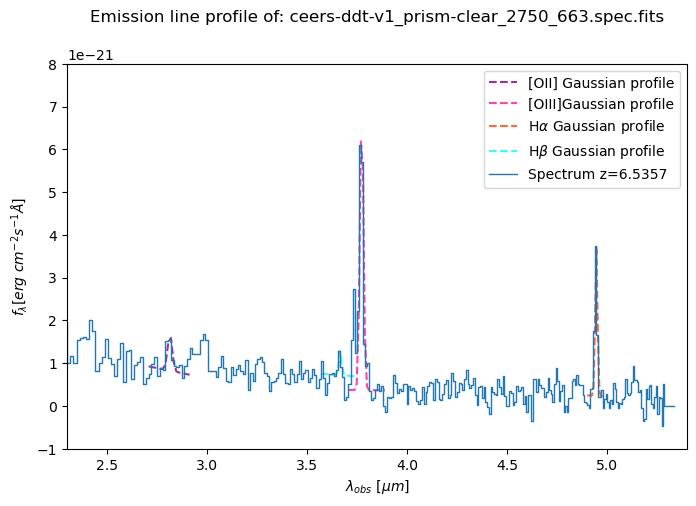

In [18]:
### Graph data for emission lines
plt.figure(figsize=(8, 5))
#plt.step(x, y, label='Full data z=5.66',c='red')
plt.title('Emission line profile of: '+filename+"\n")
#plt.step(x,flux1,label="Norm spectrum z=5.66")
plt.plot(x[(x >= 2.7) & (x <= 2.92)], y_fit1[(x >= 2.7) & (x <= 2.92)], alpha=0.8,color="purple",linestyle="--", label=r'[OII] Gaussian profile')
plt.plot(x[(x >= 3.7) & (x <= 3.9)], y_fit2[(x >= 3.7) & (x <= 3.9)],alpha=0.8, color='deeppink',linestyle="--", label='[OIII]Gaussian profile')
plt.plot(x[(x >= 4.9) & (x <= 5.)], y_fit[(x >= 4.9) & (x <= 5.)], alpha=0.8,color="orangered",linestyle="--", label=r'H$\alpha$ Gaussian profile')
plt.plot(x[(x >= 3.56) & (x <= 3.75)], y_fit3[(x >= 3.56) & (x <= 3.75)], alpha=0.8,color="aqua",linestyle="--", label=r'H$\beta$ Gaussian profile')

plt.xlabel("$\lambda_{obs}$ [$\mu m $]")
plt.ylabel(r"$f_{\lambda} [erg ~ cm^{-2} s^{-1} \AA$]")
plt.step(wave,flux1,label="Spectrum z="+str(zobj2),linewidth=1)
#plt.errorbar(cont_norm_spec.spectral_axis,cont_norm_sp3ec.flux,yerr=sigma,elinewidth=0.1,fmt="o",capsize=0.1,color='orchid')
plt.xlim(2.3,5.4)
plt.ylim(-0.1e-20,0.8e-20)

plt.legend()
plt.savefig('2750_663.png', dpi=300, bbox_inches='tight')
plt.show()
#plt.plot(x_restricted1, y_restricted1*0.1e16, color='lightseagreen',linestyle="-")#label='Restricted data [OII]'
#plt.fill_betweenx(4,5, color='gray', alpha=0.3)
#plt.plot(x_restricted2, y_restricted2*0.1e16, color='lightseagreen',linestyle="-")#label='Restricted data [OIII]'
#plt.plot(x_restricted, y_restricted*0.1e16, color='lightseagreen',linestyle="-")# label=r'Restricted data H$\alpha$'

In [19]:
#Print results of the fit
print("Results [OII]")
print(f"Amplitude : {popt1[0]:.2f} ± {perr1[0]:.5f}")

print(f"Center (x0): {popt1[1]:.2f} ± {perr1[1]:.5f}")
print(f"Width (sigma): {popt1[2]:.2f} ± {perr1[2]:.5f}\n")

print("Results [OIII]")
print(f"Amplitude : {popt2[0]:.2f} ± {perr2[0]:.5f}")
print(f"Center (x0): {popt2[1]:.2f} ± {perr2[1]:.5f}")
print(f"Width (sigma): {popt2[2]:.2f} ± {perr2[2]:.5f}\n")

print(r"Results $H_{\alpha}$")
print(f"Amplitude: {popt[0]:.2f} ± {perr[0]:.5f}")
print(f"Center(x0): {popt[1]:.2f} ± {perr[1]:.5f}")
print(f"Width(sigma): {popt[2]:.2f} ± {perr[2]:.5f}\n")

print(r"Results $H_{\beta}$")
print(f"Amplitude: {popt3[0]:.2f} ± {perr3[0]:.5f}")
print(f"Center(x0): {popt3[1]:.2f} ± {perr3[1]:.5f}")
print(f"Width(sigma): {popt3[2]:.2f} ± {perr3[2]:.5f}\n")

Results [OII]
Amplitude : 0.00 ± 0.00000
Center (x0): 2.81 ± 0.00408
Width (sigma): 0.01 ± 0.00462

Results [OIII]
Amplitude : 0.00 ± 0.00000
Center (x0): 3.77 ± 0.00038
Width (sigma): 0.01 ± 0.00041

Results $H_{\alpha}$
Amplitude: 0.00 ± 0.00000
Center(x0): 4.95 ± 0.00050
Width(sigma): 0.01 ± 0.00043

Results $H_{\beta}$
Amplitude: 0.00 ± 0.00000
Center(x0): 3.67 ± 0.01215
Width(sigma): 0.01 ± 0.00847



In [20]:
#FWHM Halfa
fwhm_ha=2.35*perr[0]
print('FWHM Halpha',fwhm_ha)

#Luminosity and SFR calculations
#Calculate integrated flux
fline_ha=np.sqrt(2*np.pi)*popt[0]*popt[2]*1e4
fline_OIII=np.sqrt(2*np.pi)*popt2[0]*popt2[2]*1e4
fline_OII=np.sqrt(2*np.pi)*popt1[0]*popt1[2]*1e4
fline_hb=np.sqrt(2*np.pi)*popt3[0]*popt3[2]*1e4

#Luminosity distance from cosmocalc
dl=65151.0 
D_L=dl*3.08568e24

#Luminosity calculations
L_ha=4*np.pi*(D_L**2)*fline_ha
L_OIII=4*np.pi*(D_L**2)*fline_OIII
L_OII=4*np.pi*(D_L**2)*fline_OII
L_hb=4*np.pi*(D_L**2)*fline_hb

#Star formation rate
SFR_ha= 7.9e-42*L_ha
Lerr=perr[0]*4*np.pi*(D_L**2)
print('Luminosity Halpha:',L_ha)
print('Star formation rate',SFR_ha)

#For sigma NII
imin=zobj2*0.6600+0.6600
imax=zobj2*0.6700+0.6700
intervalo=np.where((x>=imin)&(x<=imax))
std12=np.std(y[intervalo])
sigma3=3*std12
fline_NII=np.sqrt(2*np.pi)*sigma3*popt[2]*1e4

FWHM Halpha 5.621688322350492e-22
Luminosity Halpha: 2.5862525281393038e+41
Star formation rate 2.04313949723005


## Third part: Fit of the Lyman $\alpha$ region

In this section we fit the Lyman $\alpha$ region using Tepper-Garcia et al., 2006 semi-analytical approximation.
The function generates the profiles with different neutral hydrogen content to later fit to our data. This section includes a $\chi^2$ calculation to evaluate the model. 

Reduced $\chi^2$ 3.6642971550982795


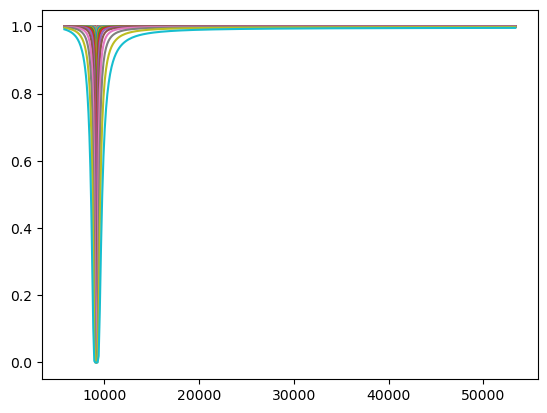

In [23]:
# ==== VOIGT PROFILE ===============
import scipy.integrate as integrate

def H(a, x):
    """Voigt Profile Approximation from T. Tepper-Garcia (2006, 2007)."""
    P = x**2
    H0 = np.exp(-x**2)
    Q = 1.5/x**2
    return H0 - a/np.sqrt(np.pi)/P * (H0*H0*(4.*P*P + 7.*P + 4. + Q) - Q - 1)

def Voigt(wl, l0, f, N, b, gam, z=0):
    """
    Calculate the optical depth Voigt profile.
    Parameters
    ----------
    wl : array_like, shape (N)
        Wavelength grid in Angstroms at which to evaluate the optical depth.
    l0 : float
        Rest frame transition wavelength in Angstroms.
        Oscillator strength.
    f : float
    N : float
        Column density in units of cm^-2.
    b : float
        Velocity width of the Voigt profile in cm/s.
    gam : float
        Radiation damping constant, or Einstein constant (A_ul)
    z : float
        The redshift of the observed wavelength grid `l`.
    Returns
    -------***
    tau : array_like, shape (N)
        Optical depth array evaluated at the input grid wavelengths `l`.
    """
    # ==== PARAMETERS ==================
    c = 2.99792e10        # cm/s
    m_e = 9.1094e-28       # g
    e = 4.8032e-10        # cgs units
    # ==================================
    # Calculate Profile
    C_a = np.sqrt(np.pi)*e**2*f*l0*1.e-8/m_e/c/b
    a = l0*1.e-8*gam/(4.*np.pi*b)
    # dl_D = b/c*l0
    wl = wl/(z+1.)
    # x = (wl - l0)/dl_D + 0.000001
    x = (c / b) * (1. - l0/wl)
    tau = np.float64(C_a) * N * H(a, x)
    return tau
 

# Make an array of column densities
N = 10**np.linspace(17,23,20)    
wave_l = 1215.6701    # atomic quantities for HI Lya
gamma = 6.265e+08
f_ij= 0.41640

b=2.e6              #  choose Doppler parameter in cm/s   (2e6 cm = 20 km/s) 
wl= wave*1e4# make a wavelength array,I changed to angstroms
ew_res=[]

# Main code
zobj = zobj2
lobs = wave_l * (1 + zobj)

# CHANGE 1: use len(wl), because spectrum is not defined yet
list2 = np.zeros(len(wl))

interval = np.where((lobs < wl) & (wl < 1))

for id_N in N:
     # Keep your original redshift treatment
     # Here wl is shifted to rest frame before entering Voigt()
     tau = Voigt(wl/(zobj+1), wave_l, f_ij, id_N, b, gamma)

     spectrum = np.exp(-tau)     # Generate spectrum 
     plt.plot(wl, spectrum)

     # Stack each Voigt profile into list2
     list2 = np.vstack([list2, spectrum])

# Select one Voigt profile
newlist = list2[9, :] # 14

minimum = np.min(newlist)
indexa = np.argmin(newlist)

# Keep only the profile after minimum
listfinal2 = newlist[indexa:] # 49

# Create zeros before the profile
zerosl2 = list(np.zeros(len(spectrum) - len(listfinal2)))
zerosl2.extend(listfinal2)

#Final list
listf = np.array(zerosl2)

# Gaussian filter to correct instrument problems
filter2 = gaussian_filter1d(input=listf, sigma=3.8e-3)

# Error in Voigt profile
indices = (x >= 0.9) & (x <= 1.1)

aflux = cont_norm_spec.flux.to_value()
sigma = errorn.flux.to_value()

# Calculate reduced chi-square for Lyman alpha fit
chi_s = np.sum(((aflux[indices] - filter2[indices])**2) / (sigma[indices])**2)

dof = len(aflux[indices]) - 1 # Degree of freedom
errorv = chi_s / dof

print('Reduced $\chi^2$', errorv)

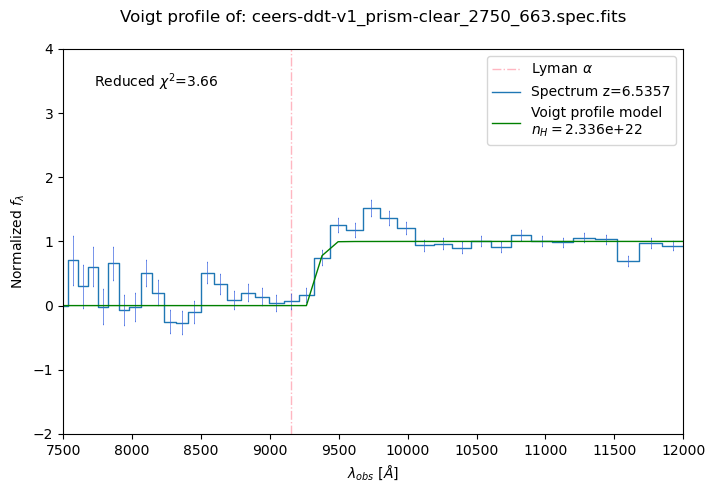

In [24]:
##Graph data for Lyman alfa break
plt.figure(figsize=(8, 5))
lobs2=zobj2*0.1215 +0.1215
plt.axvline(lobs2*1e4,color='lightpink',linestyle="-.",linewidth=1,label=r'Lyman $\alpha$ ')
plt.step(wavef,cont_norm_spec.flux,label='Spectrum z=6.5357',linewidth=1,where='mid')
plt.errorbar(wavef,cont_norm_spec.flux.to_value(),yerr=abs(errors)/abs(facF),linewidth=0.5,capsize=0.3,color='royalblue',ls='none')

plt.ylim(-2,4)
plt.xlim(7500,12000)
plt.ylabel(r"Normalized $f_{\lambda}$")
plt.xlabel("$\lambda_{obs}$ [$\AA $]")
plt.title('Voigt profile of: '+filename+"\n")

cd = N[17] #Selected column density
Nf = f"{cd:.3e}" 
plt.plot(wavef,filter2,color="green",linewidth=1,label='Voigt profile model\n$n_H=$'+str(Nf),linestyle='-')
plt.text(0.05, 0.90,'Reduced $\chi^2$='+str(np.round(errorv,2)),transform=plt.gca().transAxes)
plt.legend()

#Save fit
#plt.savefig('2750_663v.png', dpi=300)

#Save data
#with open("Spectradata_2.txt", "w") as archivo:
 #   archivo.write("Name\tz\tFluxha\tErrorFluxha\tFluxOIII\tErrorFluxOIII\tFluxOII\tErrorFluxOII\tHbeta\tErrorFluxhb\tLumha\tLerr\tSFRha\tColumden\tErrorVoigt\tsigma3\twha\tfline_NII\n")  # Encabezado con tabulaciones
  #  archivo.write(f"{filename}\t{zobj}\t{fline_ha}\t{perr[0]}\t{fline_OIII}\tf{perr2[0]}\t{fline_OII}\t{perr1[0]}\t{fline_hb}\t{perr3[0]}\t{L_ha}\t{Lerr}\t{SFR_ha}\t{N[17]}\t{errorv}\t{sigma3}\t{popt[2]}\t{fline_NII}")

The best fit model is for object "whl0137-v1_prism-clear_2282_10200.spec" with reduced $\chi^2$=1.2.